# **Exploratory Analysis and Quality Assessment of a Public Gene Expression Dataset**

## GSE37084 — Myotonic Dystrophy Type 2

This project investigates a publicly available gene expression dataset from the NCBI Gene Expression Omnibus (GEO).

The study compares skeletal muscle gene expression profiles from individuals with Myotonic Dystrophy Type 2 (DM2) and control individuals.

### Primary objective

To explore and assess the structure and quality of the processed gene expression dataset using Python and Pandas, while developing an understanding of the biological meaning of the data.

### Dataset

- GEO accession: GSE37084
- Organism: Homo sapiens
- Tissue: Skeletal muscle
- Experimental groups: DM2 and control
- Samples: 20
- Platform: Affymetrix Human Exon 1.0 ST Array

### Primary computational tool

Python Pandas

In [5]:
from google.colab import files

uploaded = files.upload()

Saving GSE37084_series_matrix.txt.gz to GSE37084_series_matrix.txt.gz


In [6]:
import numpy as np

import pandas as pd

## Understanding the DataFrame Structure

## Understanding the DataFrame Structure

A Pandas DataFrame is a two-dimensional table where rows represent observations and columns represent variables. In biological datasets, each row or column can have a specific scientific meaning depending on how the dataset is structured.


In [7]:
# Creating a small example gene-expression dataset

data = {
    "sample" : ["S1", "S2", "S3", "S4"],
    "condition" : ["Control", "Control", "DM2", "DM2"],
    "expression" : [7.2, 6.8, 8.1, 8.5]
}

df_demo = pd.DataFrame(data)

df_demo

,sample,condition,expression
0,S1,Control,7.2
1,S2,Control,6.8
2,S3,DM2,8.1
3,S4,DM2,8.5


In [8]:
df_demo.shape

(4, 3)

In [9]:
import gzip

with gzip.open("GSE37084_series_matrix.txt.gz", "rt") as file:
    for i in range(10):
        print(file.readline().strip())

!Series_title	"Transcriptome analysis of Myotonic Dystrophy type 2 (DM2) patients."
!Series_geo_accession	"GSE37084"
!Series_status	"Public on Apr 05 2015"
!Series_submission_date	"Apr 06 2012"
!Series_last_update_date	"Feb 18 2019"
!Series_pubmed_id	"24722564"
!Series_summary	"Myotonic Dystrophy Type-2 (DM2) is an autosomal dominant disease caused by the expansion of a CCTG tetraplet repeat. It is a multisystemic disorder, affecting skeletal muscles, the heart, the eye, the central nervous system and the endocrine system."
!Series_summary	"Whole mRNAs expression was measured in the muscle of DM2 patients and compared it to controls.We identified distinct genes modulated in DM2 patients compared to controls."
!Series_overall_design	"Our study included 10 DM2 and 10 control (CTR) muscle biopsies from biceps brachii. DM2 and CTR were age- and sex- matched. Most DM2 patients had myotonia and cataract, two disease hallmarks, while differences in other clinical parameters (muscle strenght, 

### Understanding the Relationship Between Expression Data and Sample Metadata

The expression matrix tells us **what was measured**, while the sample metadata tells us **what biological sample the measurement belongs to**.

A useful mental model is:

Expression matrix
→ tells us: "How much expression was measured?"

Sample metadata
→ tells us: "Which biological sample and experimental condition does this measurement belong to?"

For example:

GSM910396
→ expression value for a particular probe = 6.38
→ sample metadata = biceps brachii, CONTROL

Therefore, the expression value alone does not tell us whether a sample is Control or DM2. We determine the biological condition from the corresponding sample metadata.

### Three Important Layers

1. **ID_REF**
   → identifies the expression feature/probe.

2. **GSM accession**
   → identifies the biological sample.

3. **Sample metadata**
   → describes characteristics of the biological sample, such as tissue and experimental condition (Control or DM2).

In [10]:
with gzip.open("GSE37084_series_matrix.txt.gz", "rt") as file:
    for i in range(40):
        line = file.readline().strip()
        print(line)

!Series_title	"Transcriptome analysis of Myotonic Dystrophy type 2 (DM2) patients."
!Series_geo_accession	"GSE37084"
!Series_status	"Public on Apr 05 2015"
!Series_submission_date	"Apr 06 2012"
!Series_last_update_date	"Feb 18 2019"
!Series_pubmed_id	"24722564"
!Series_summary	"Myotonic Dystrophy Type-2 (DM2) is an autosomal dominant disease caused by the expansion of a CCTG tetraplet repeat. It is a multisystemic disorder, affecting skeletal muscles, the heart, the eye, the central nervous system and the endocrine system."
!Series_summary	"Whole mRNAs expression was measured in the muscle of DM2 patients and compared it to controls.We identified distinct genes modulated in DM2 patients compared to controls."
!Series_overall_design	"Our study included 10 DM2 and 10 control (CTR) muscle biopsies from biceps brachii. DM2 and CTR were age- and sex- matched. Most DM2 patients had myotonia and cataract, two disease hallmarks, while differences in other clinical parameters (muscle strenght, 

In [11]:
with gzip.open("GSE37084_series_matrix.txt.gz", "rt") as file:
    for i, line in enumerate(file):
        if line.startswith("!series_matrix_table_begin"):
            print("Expression matrix begins at line:", i)
            break

Expression matrix begins at line: 65


In [12]:
with gzip.open("GSE37084_series_matrix.txt.gz", "rt") as file:
    for i, line in enumerate(file):
        if 65 <= i <= 70:
            print(line.strip())

!series_matrix_table_begin
"ID_REF"	"GSM910396"	"GSM910397"	"GSM910398"	"GSM910399"	"GSM910400"	"GSM910401"	"GSM910402"	"GSM910403"	"GSM910404"	"GSM910405"	"GSM910406"	"GSM910407"	"GSM910408"	"GSM910409"	"GSM910410"	"GSM910411"	"GSM910412"	"GSM910413"	"GSM910414"	"GSM910415"
2315554	6.38	6.52	6.44	6.49	6.50	6.26	6.45	6.47	6.91	6.12	6.55	6.58	6.31	5.90	7.16	6.23	6.21	6.38	6.65	6.85
2315633	6.73	6.69	6.36	6.55	6.37	6.36	6.42	6.43	6.84	6.35	6.63	6.48	6.35	6.23	6.83	6.46	6.41	6.62	6.62	6.78
2315674	6.49	6.58	6.31	6.46	6.46	6.07	6.21	6.47	6.76	6.13	6.65	6.67	6.35	5.72	7.06	6.35	6.14	6.34	6.58	6.86
2315739	6.55	6.65	6.52	6.59	6.39	6.38	6.41	6.59	6.75	6.42	6.75	6.55	6.17	6.29	6.91	6.54	6.13	6.53	6.71	6.47


In [13]:
# Loading the GEO expression matrix

df = pd.read_csv(
    "GSE37084_series_matrix.txt.gz",
    sep="\t",
    skiprows=66
)

In [14]:
df.head()

,ID_REF,GSM910396,GSM910397,GSM910398,GSM910399,GSM910400,GSM910401,GSM910402,GSM910403,GSM910404,...,GSM910406,GSM910407,GSM910408,GSM910409,GSM910410,GSM910411,GSM910412,GSM910413,GSM910414,GSM910415
0,2315554,6.38,6.52,6.44,6.49,6.50,6.26,6.45,6.47,6.91,...,6.55,6.58,6.31,5.90,7.16,6.23,6.21,6.38,6.65,6.85
1,2315633,6.73,6.69,6.36,6.55,6.37,6.36,6.42,6.43,6.84,...,6.63,6.48,6.35,6.23,6.83,6.46,6.41,6.62,6.62,6.78
2,2315674,6.49,6.58,6.31,6.46,6.46,6.07,6.21,6.47,6.76,...,6.65,6.67,6.35,5.72,7.06,6.35,6.14,6.34,6.58,6.86
3,2315739,6.55,6.65,6.52,6.59,6.39,6.38,6.41,6.59,6.75,...,6.75,6.55,6.17,6.29,6.91,6.54,6.13,6.53,6.71,6.47
4,2315894,8.92,8.96,8.56,8.67,8.60,8.51,8.56,8.65,8.67,...,8.81,8.75,8.60,8.02,9.13,8.51,8.29,8.60,9.07,8.80


### **Initial Structure of the Expression Matrix**

The GEO Series Matrix contains a feature-by-sample expression matrix.

- Each row represents an expression feature/probe identified by `ID_REF`.
- Each sample is represented by a GEO sample accession (`GSM`).
- Each numerical value represents the measured expression value of a feature in a particular sample.
- The dataset contains 20 biological samples: 10 Control samples and 10 DM2 samples.
- Therefore, the expression matrix contains 21 columns: 1 feature identifier column (`ID_REF`) and 20 sample columns.

At this stage, the expression matrix does not yet contain the biological condition (Control or DM2) as a dedicated column. We will obtain that information from the sample metadata and connect the two later.

In [15]:
df.shape

(22012, 21)

### Inspecting Column Labels

The `df.columns` attribute returns the labels of all columns in the DataFrame.

In this dataset:

- `ID_REF` is the identifier for each expression feature/probe.
- `GSM910396` through `GSM910415` are GEO sample accession identifiers.
- The 20 GSM columns correspond to the 20 biological samples included in the study.

In [16]:
# Selecting the expression values for one sample

df["GSM910396"]

,GSM910396
0,6.38
1,6.73
2,6.49
3,6.55
4,8.92
...,...
22007,6.06
22008,6.46
22009,5.65
22010,8.76


In [17]:
# Checking which expression values are missing

df["GSM910396"].isna()

,GSM910396
0,False
1,False
2,False
3,False
4,False
...,...
22007,False
22008,False
22009,False
22010,False


In [18]:
# Counting the number of missing expression values

df["GSM910396"].isna().sum()

np.int64(1)

In [19]:
# Identifying which columns are sample columns based on GSM naming pattern

df.columns.str.startswith("GSM")

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [20]:
# Selecting  the 20 biological sample columns from the expression matrix

sample_df = df.loc[:, df.columns.str.startswith("GSM")]

sample_df.shape

(22012, 20)

In [21]:
# Counting missing expression measurements in each biological sample

sample_df.isna().sum()

,0
GSM910396,1
GSM910397,1
GSM910398,1
GSM910399,1
GSM910400,1
GSM910401,1
GSM910402,1
GSM910403,1
GSM910404,1
GSM910405,1


In [22]:
# Inspecting the feature corresponding to the missing values in all samples

df.loc[22011]

,22011
ID_REF,!series_matrix_table_end
GSM910396,NaN
GSM910397,NaN
GSM910398,NaN
GSM910399,NaN
GSM910400,NaN
GSM910401,NaN
GSM910402,NaN
GSM910403,NaN
GSM910404,NaN


In [23]:
df[df["ID_REF"] != "!series_matrix_table_end"].shape

(22011, 21)

In [24]:
# Removing the GEO table-ending marker from the expression matrix

clean_df = df[df["ID_REF"] != "!series_matrix_table_end"]

clean_df.shape

(22011, 21)

In [25]:
# Selecting the 20 biological sample columns from the cleaned expression matrix

clean_sample_df = clean_df.loc[:, clean_df.columns.str.startswith("GSM")]

# Counting missing expression measurements in each sample

clean_sample_df.isna().sum()

,0
GSM910396,0
GSM910397,0
GSM910398,0
GSM910399,0
GSM910400,0
GSM910401,0
GSM910402,0
GSM910403,0
GSM910404,0
GSM910405,0


In [26]:
# Checking the data types of expression measurements

clean_sample_df.dtypes

,0
GSM910396,float64
GSM910397,float64
GSM910398,float64
GSM910399,float64
GSM910400,float64
GSM910401,float64
GSM910402,float64
GSM910403,float64
GSM910404,float64
GSM910405,float64


In [27]:
# Generating summmary statistics for the expression results

clean_sample_df.describe()

,GSM910396,GSM910397,GSM910398,GSM910399,GSM910400,GSM910401,GSM910402,GSM910403,GSM910404,GSM910405,GSM910406,GSM910407,GSM910408,GSM910409,GSM910410,GSM910411,GSM910412,GSM910413,GSM910414,GSM910415
count,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000,22011.000000
mean,6.084732,6.093924,6.084097,6.120779,6.114338,6.079380,6.123953,6.098476,6.104810,6.109591,6.084356,6.089148,6.065944,6.076055,6.167151,6.095599,6.096022,6.088692,6.102393,6.159989
std,1.854931,1.835675,1.850530,1.821710,1.816547,1.851558,1.813046,1.829712,1.801315,1.847712,1.851498,1.848516,1.830885,1.875607,1.709667,1.831384,1.847160,1.855017,1.827178,1.740657
min,1.160000,1.260000,1.160000,1.290000,1.250000,1.150000,1.290000,1.230000,1.250000,1.080000,1.140000,1.200000,1.260000,1.220000,1.210000,1.170000,1.260000,1.280000,1.220000,1.210000
25%,4.890000,4.910000,4.880000,4.940000,4.950000,4.860000,4.980000,4.940000,5.010000,4.910000,4.910000,4.930000,4.940000,4.810000,5.190000,4.920000,4.900000,4.900000,4.940000,5.130000
50%,6.060000,6.070000,6.050000,6.060000,6.010000,6.020000,6.070000,6.050000,6.110000,6.000000,6.090000,6.090000,6.060000,5.980000,6.150000,6.040000,6.000000,6.050000,6.080000,6.150000
75%,7.130000,7.120000,7.120000,7.130000,7.110000,7.120000,7.090000,7.100000,7.060000,7.150000,7.110000,7.090000,7.050000,7.140000,7.010000,7.100000,7.110000,7.120000,7.090000,7.040000
max,13.290000,13.220000,13.220000,13.190000,13.260000,13.260000,13.400000,13.300000,13.280000,13.290000,13.260000,13.250000,13.350000,13.320000,13.310000,13.270000,13.420000,13.220000,13.180000,13.260000


In [28]:
clean_sample_df.mean()

,0
GSM910396,6.084732
GSM910397,6.093924
GSM910398,6.084097
GSM910399,6.120779
GSM910400,6.114338
GSM910401,6.079380
GSM910402,6.123953
GSM910403,6.098476
GSM910404,6.104810
GSM910405,6.109591


In [29]:
# Calculating the standard deviation of expression values for each biological sample

clean_sample_df.std()

,0
GSM910396,1.854931
GSM910397,1.835675
GSM910398,1.850530
GSM910399,1.821710
GSM910400,1.816547
GSM910401,1.851558
GSM910402,1.813046
GSM910403,1.829712
GSM910404,1.801315
GSM910405,1.847712


### **Sample Metadata**

The GSE37084 study contains 20 biceps brachii muscle biopsy samples:
10 Control samples and 10 Myotonic Dystrophy type 2 (DM2) samples.

The GEO sample records identify GSM910396–GSM910405 as Control samples and GSM910406–GSM910415 as DM2 samples.

In [30]:
# Displaying the sample IDs in cleaned expression matrix

clean_sample_df.columns

Index(['GSM910396', 'GSM910397', 'GSM910398', 'GSM910399', 'GSM910400',
       'GSM910401', 'GSM910402', 'GSM910403', 'GSM910404', 'GSM910405',
       'GSM910406', 'GSM910407', 'GSM910408', 'GSM910409', 'GSM910410',
       'GSM910411', 'GSM910412', 'GSM910413', 'GSM910414', 'GSM910415'],
      dtype='object')

In [31]:
groups = {
    "Control": [
        "GSM910396",
        "GSM910397",
        "GSM910398",
        "GSM910399",
        "GSM910400",
        "GSM910401",
        "GSM910402",
        "GSM910403",
        "GSM910404",
        "GSM910405"
    ],
    "DM2": [
        "GSM910406",
        "GSM910407",
        "GSM910408",
        "GSM910409",
        "GSM910410",
        "GSM910411",
        "GSM910412",
        "GSM910413",
        "GSM910414",
        "GSM910415"
    ]
}

In [32]:
# Checking how many samples are assigned to each biological group

{group: len(samples) for group, samples in groups.items()}

{'Control': 10, 'DM2': 10}

In [33]:
# Creating a sample metadata table linking each sample to its biological group

sample_metadata = pd.DataFrame({
    "Sample": groups["Control"] + groups["DM2"],
    "Group": ["Control"] * 10 + ["DM2"] * 10
})

sample_metadata

,Sample,Group
0,GSM910396,Control
1,GSM910397,Control
2,GSM910398,Control
3,GSM910399,Control
4,GSM910400,Control
5,GSM910401,Control
6,GSM910402,Control
7,GSM910403,Control
8,GSM910404,Control
9,GSM910405,Control


In [34]:
# Calculating average expression value around all control samples

control_mean = clean_sample_df[groups["Control"]].mean().mean()

control_mean

np.float64(6.101408023261097)

In [35]:
# Calculaating average expression value arround all DM2 samples

dm2_mean = clean_sample_df[groups["DM2"]].mean().mean()

dm2_mean

np.float64(6.102534778065513)

In [36]:
# Calculating the mean expression of each feature within each biological group

control_feature_mean = clean_sample_df[groups["Control"]].mean(axis = 1)

dm_2_feature_meen = clean_sample_df[groups["Control"]].mean(axis = 1)

In [37]:
# Calculating the exploratory difference in mean expression between DM2 and Control

feature_difference = dm_2_feature_meen - control_feature_mean

feature_difference.head()

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [38]:
type(feature_difference), feature_difference.shape

(pandas.core.series.Series, (22011,))

In [39]:
# Checking the smallest and largest Control-vs-DM2 differences

feature_difference.min(), feature_difference.max()

(0.0, 0.0)

In [40]:
# Calculating the mean expression of each feature within each biological group

control_feature_mean = clean_sample_df[groups["Control"]].mean(axis=1)
dm2_feature_mean = clean_sample_df[groups["DM2"]].mean(axis=1)

control_feature_mean.head(), dm2_feature_mean.head()

(0    6.454
 1    6.510
 2    6.394
 3    6.525
 4    8.639
 dtype: float64,
 0    6.482
 1    6.541
 2    6.472
 3    6.505
 4    8.658
 dtype: float64)

In [41]:
# Calculating the exploratory mean difference for every expression feature

feature_difference = dm2_feature_mean - control_feature_mean

feature_difference.head()

,0
0,0.028
1,0.031
2,0.078
3,-0.020
4,0.019


In [42]:
# Identifying the range of exploratory expression differences

feature_difference.min(), feature_difference.max()

(-1.5159999999999991, 1.222999999999999)

In [43]:
feature_difference.idxmax(), feature_difference.idxmin()

(np.int64(13141), np.int64(1949))

In [44]:
df["ID_REF"].iloc[13141]

'3446868'

In [45]:
# Retrieving the ID_REF for the feature with the largest decrease

df["ID_REF"].iloc[1949]

'2441220'

In [46]:
# Identifying the 10 features with the largest exploratory increase in DM2

top_increased = feature_difference.nlargest(10)

top_increased

,0
13141,1.223
19883,1.215
3071,1.167
14293,1.114
21695,1.037
3460,1.008
9826,0.989
7891,0.984
18879,0.968
11389,0.967


In [47]:
# Identifying the 10 features with the largest exploratory decrease in DM2

top_decreased = feature_difference.nsmallest(10)

top_decreased

,0
1949,-1.516
20232,-1.227
11533,-1.210
4852,-1.174
6264,-1.158
6261,-1.097
16342,-1.084
17424,-1.000
18203,-0.917
21569,-0.917


In [48]:
# Retrieving the probe IDs corresponding to the 10 largest increases

top_increased_ids = df["ID_REF"].iloc[top_increased.index]

top_increased_ids

,ID_REF
13141,3446868
19883,3875179
3071,2550959
14293,3541383
21695,4011096
3460,2587937
9826,3210616
7891,2992243
18879,3831475
11389,3333086


In [49]:
# Retrieving the probe IDs corresponding to the 10 largest decreases

top_decreased_ids = df["ID_REF"].iloc[top_decreased.index]

top_decreased_ids

,ID_REF
1949,2441220
20232,3903598
11533,3336324
4852,2723752
6264,2844387
6261,2844381
16342,3695541
17424,3745287
18203,3806211
21569,3996598


In [50]:
# Combining group means and exploratory differences into one feature-level results table

feature_results = pd.DataFrame({
    "Control_mean": control_feature_mean,
    "DM2_mean": dm2_feature_mean,
    "Difference": feature_difference
})

feature_results.head()

,Control_mean,DM2_mean,Difference
0,6.454,6.482,0.028
1,6.510,6.541,0.031
2,6.394,6.472,0.078
3,6.525,6.505,-0.020
4,8.639,8.658,0.019


In [51]:
# Adding the probe identifiers corresponding only to the actual expression features

feature_results["ID_REF"] = df["ID_REF"].iloc[:-1].values

feature_results.head()

,Control_mean,DM2_mean,Difference,ID_REF
0,6.454,6.482,0.028,2315554
1,6.510,6.541,0.031,2315633
2,6.394,6.472,0.078,2315674
3,6.525,6.505,-0.020,2315739
4,8.639,8.658,0.019,2315894


In [52]:
# Ranking expression features by their exploratory DM2-vs-Control difference

feature_results_sorted = feature_results.sort_values(
    "Difference",
    ascending=False
)

feature_results_sorted.head(10)

,Control_mean,DM2_mean,Difference,ID_REF
13141,7.274,8.497,1.223,3446868
19883,4.421,5.636,1.215,3875179
3071,7.547,8.714,1.167,2550959
14293,5.800,6.914,1.114,3541383
21695,5.654,6.691,1.037,4011096
3460,7.232,8.240,1.008,2587937
9826,4.927,5.916,0.989,3210616
7891,4.172,5.156,0.984,2992243
18879,5.295,6.263,0.968,3831475
11389,6.273,7.240,0.967,3333086


In [53]:
# Ranking expression features by the largest decrease in DM2 relative to Control

feature_results_sorted_decreased = feature_results.sort_values(
    "Difference",
    ascending=True
)

feature_results_sorted_decreased.head(10)

,Control_mean,DM2_mean,Difference,ID_REF
1949,6.985,5.469,-1.516,2441220
20232,8.068,6.841,-1.227,3903598
11533,11.069,9.859,-1.210,3336324
4852,8.521,7.347,-1.174,2723752
6264,2.782,1.624,-1.158,2844387
6261,5.492,4.395,-1.097,2844381
16342,8.149,7.065,-1.084,3695541
17424,8.806,7.806,-1.000,3745287
18203,7.553,6.636,-0.917,3806211
21569,4.195,3.278,-0.917,3996598


In [54]:
# Calculating the mean expression across all features for each biological sample

sample_means = clean_sample_df.mean()

sample_means

,0
GSM910396,6.084732
GSM910397,6.093924
GSM910398,6.084097
GSM910399,6.120779
GSM910400,6.114338
GSM910401,6.079380
GSM910402,6.123953
GSM910403,6.098476
GSM910404,6.104810
GSM910405,6.109591


In [55]:
# Measuring the range of overall mean expression across samples

sample_means.min(), sample_means.max()

(6.065943846258689, 6.167150515651265)

In [56]:
# Identifying the samples with the lowest and highest overall mean expression

sample_means.idxmin(), sample_means.idxmax()

('GSM910408', 'GSM910410')

In [57]:
# Calculating the standard deviation across all features for each biological sample

sample_stds = clean_sample_df.std()

sample_stds

,0
GSM910396,1.854931
GSM910397,1.835675
GSM910398,1.850530
GSM910399,1.821710
GSM910400,1.816547
GSM910401,1.851558
GSM910402,1.813046
GSM910403,1.829712
GSM910404,1.801315
GSM910405,1.847712


In [58]:
# Measuring the range of expression variability across samples

sample_stds.min(), sample_stds.max()

(1.7096669328759546, 1.8756074402267295)

In [59]:
# Identifying the samples with the lowest and highest expression variability

sample_stds.idxmin(), sample_stds.idxmax()

('GSM910410', 'GSM910409')

In [60]:
clean_sample_df.describe().loc[["min", "25%", "50%", "75%", "max"]]

,GSM910396,GSM910397,GSM910398,GSM910399,GSM910400,GSM910401,GSM910402,GSM910403,GSM910404,GSM910405,GSM910406,GSM910407,GSM910408,GSM910409,GSM910410,GSM910411,GSM910412,GSM910413,GSM910414,GSM910415
min,1.16,1.26,1.16,1.29,1.25,1.15,1.29,1.23,1.25,1.08,1.14,1.20,1.26,1.22,1.21,1.17,1.26,1.28,1.22,1.21
25%,4.89,4.91,4.88,4.94,4.95,4.86,4.98,4.94,5.01,4.91,4.91,4.93,4.94,4.81,5.19,4.92,4.90,4.90,4.94,5.13
50%,6.06,6.07,6.05,6.06,6.01,6.02,6.07,6.05,6.11,6.00,6.09,6.09,6.06,5.98,6.15,6.04,6.00,6.05,6.08,6.15
75%,7.13,7.12,7.12,7.13,7.11,7.12,7.09,7.10,7.06,7.15,7.11,7.09,7.05,7.14,7.01,7.10,7.11,7.12,7.09,7.04
max,13.29,13.22,13.22,13.19,13.26,13.26,13.40,13.30,13.28,13.29,13.26,13.25,13.35,13.32,13.31,13.27,13.42,13.22,13.18,13.26


### **Sample-Level Expression Distribution**

Boxplots are used to compare the distribution of expression measurements across the 20 biological samples. Similar distributions provide a basic indication that the samples have broadly comparable global expression profiles.

In [61]:
import matplotlib.pyplot as plt

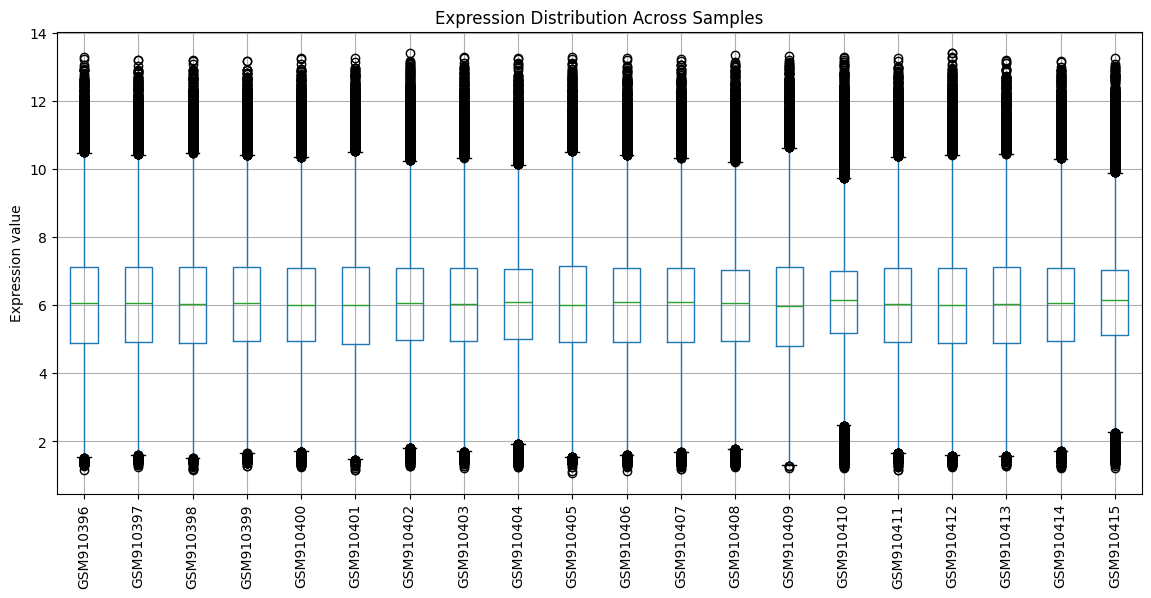

In [62]:
# Visualizing the expression distribution across all 20 biological samples

clean_sample_df.boxplot(figsize=(14, 6))

plt.xticks(rotation=90)
plt.ylabel("Expression value")
plt.title("Expression Distribution Across Samples")
plt.show()

In [63]:
# Calculating the average expression difference across all features

feature_difference.mean()

np.float64(0.0011267548044159655)

In [64]:
# Counting features showing increases, decreases, or no difference in DM2

(feature_difference > 0).sum(), (feature_difference < 0).sum(), (feature_difference == 0).sum()

(np.int64(11807), np.int64(10166), np.int64(38))

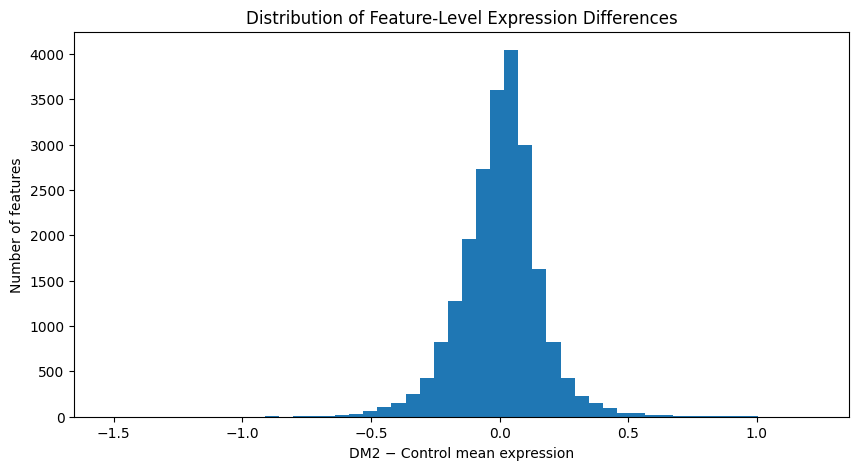

In [65]:
# Visualizing the distribution of DM2-Control expression differences

plt.figure(figsize=(10, 5))

plt.hist(feature_difference, bins=50)

plt.xlabel("DM2 − Control mean expression")
plt.ylabel("Number of features")
plt.title("Distribution of Feature-Level Expression Differences")

plt.show()

In [66]:
# Calculating the relative change in expression from Control to DM2

relative_change = (
    (dm2_feature_mean - control_feature_mean)
    / control_feature_mean
)

relative_change.head()

,0
0,0.004338
1,0.004762
2,0.012199
3,-0.003065
4,0.002199


In [67]:
# Finding the 10 features with the largest relative increase
# in expression in DM2 compared with Control

top_relative_increase = relative_change.nlargest(10)

top_relative_increase

,0
20371,0.303822
19883,0.274825
18261,0.260047
17572,0.239977
7325,0.236633
7891,0.235858
11460,0.225252
9765,0.215773
18312,0.201668
9826,0.200731


In [68]:
# Finding the 10 features with the largest relative decrease
# in expression in DM2 compared with Control

top_relative_decrease = relative_change.nsmallest(10)

top_relative_decrease

,0
6264,-0.416247
21649,-0.247604
20960,-0.235213
21569,-0.218594
1949,-0.217037
10514,-0.211121
14607,-0.208346
18311,-0.201956
10602,-0.201891
10593,-0.200706


In [69]:
# Creating a summary table containing the main expression-change measurements
# for every feature

feature_results["Relative_change"] = relative_change

feature_results.head()

,Control_mean,DM2_mean,Difference,ID_REF,Relative_change
0,6.454,6.482,0.028,2315554,0.004338
1,6.510,6.541,0.031,2315633,0.004762
2,6.394,6.472,0.078,2315674,0.012199
3,6.525,6.505,-0.020,2315739,-0.003065
4,8.639,8.658,0.019,2315894,0.002199


In [70]:
# Importing the independent two-sample t-test function
# from SciPy for comparing Control and DM2 expression

from scipy.stats import ttest_ind

In [71]:
# Performing an independent two-sample t-test for every feature
# to compare expression between Control and DM2 samples

p_values = []

for i in range(len(clean_sample_df)):
    control_values = clean_sample_df.iloc[i][groups["Control"]]
    dm2_values = clean_sample_df.iloc[i][groups["DM2"]]

    _, p_value = ttest_ind(control_values, dm2_values)
    p_values.append(p_value)

p_values[:5]

[np.float64(0.8320845051808271),
 np.float64(0.712631026835232),
 np.float64(0.5784240194694239),
 np.float64(0.824269572275499),
 np.float64(0.8785242867574077)]

In [72]:
# Adding the p-values from the t-tests to our feature results table
# so that expression changes and statistical significance are stored together

feature_results["p_value"] = p_values

feature_results.head()

,Control_mean,DM2_mean,Difference,ID_REF,Relative_change,p_value
0,6.454,6.482,0.028,2315554,0.004338,0.832085
1,6.510,6.541,0.031,2315633,0.004762,0.712631
2,6.394,6.472,0.078,2315674,0.012199,0.578424
3,6.525,6.505,-0.020,2315739,-0.003065,0.824270
4,8.639,8.658,0.019,2315894,0.002199,0.878524


In [73]:
# Importing the Benjamini-Hochberg method for correcting
# p-values from multiple statistical tests

from statsmodels.stats.multitest import multipletests

In [74]:
# Correcting all p-values for multiple testing using the
# Benjamini-Hochberg method and obtain FDR-adjusted p-values

rejected, adjusted_p_values, _, _ = multipletests(
    feature_results["p_value"],
    method="fdr_bh"
)

feature_results["adjusted_p_value"] = adjusted_p_values

feature_results.head()

,Control_mean,DM2_mean,Difference,ID_REF,Relative_change,p_value,adjusted_p_value
0,6.454,6.482,0.028,2315554,0.004338,0.832085,0.968094
1,6.510,6.541,0.031,2315633,0.004762,0.712631,0.945892
2,6.394,6.472,0.078,2315674,0.012199,0.578424,0.910905
3,6.525,6.505,-0.020,2315739,-0.003065,0.824270,0.966063
4,8.639,8.658,0.019,2315894,0.002199,0.878524,0.979433


In [75]:
# Counting how many features remain statistically significant
# after Benjamini-Hochberg FDR correction at the 5% level

significant_features = feature_results[
    feature_results["adjusted_p_value"] < 0.05
]

len(significant_features)

304

In [76]:
# Selecting the 304 FDR-significant features and sort them
# from the smallest to the largest adjusted p-value

significant_features_sorted = significant_features.sort_values(
    "adjusted_p_value"
)

significant_features_sorted.head(10)

,Control_mean,DM2_mean,Difference,ID_REF,Relative_change,p_value,adjusted_p_value
12475,8.826,8.422,-0.404,3396916,-0.045774,4.377032e-08,0.000340
15305,8.416,7.632,-0.784,3608466,-0.093156,6.175138e-08,0.000340
15056,7.338,7.857,0.519,3580498,0.070728,4.799667e-08,0.000340
16342,8.149,7.065,-1.084,3695541,-0.133022,2.170927e-08,0.000340
11389,6.273,7.240,0.967,3333086,0.154153,1.227481e-07,0.000540
9337,7.962,7.552,-0.410,3155937,-0.051495,2.022654e-07,0.000742
4597,10.062,9.458,-0.604,2694644,-0.060028,3.084435e-07,0.000934
10257,4.499,5.009,0.510,3252577,0.113359,3.395006e-07,0.000934
18786,8.407,7.870,-0.537,3830051,-0.063875,4.038356e-07,0.000988
7824,8.698,8.262,-0.436,2983142,-0.050126,5.404441e-07,0.001190


In [77]:
# Separating the FDR-significant features into those that increase
# and those that decrease in DM2 compared with Control

significant_increased = significant_features[
    significant_features["Difference"] > 0
]

significant_decreased = significant_features[
    significant_features["Difference"] < 0
]

print("Significantly increased:", len(significant_increased))
print("Significantly decreased:", len(significant_decreased))

Significantly increased: 72
Significantly decreased: 232


In [78]:
# Sorting significantly increased features by relative change
# to identify the features with the largest increases in DM2

top_significant_increased = significant_increased.sort_values(
    "Relative_change",
    ascending=False
)

top_significant_increased.head(10)

,Control_mean,DM2_mean,Difference,ID_REF,Relative_change,p_value,adjusted_p_value
19883,4.421,5.636,1.215,3875179,0.274825,0.000240,0.030192
7891,4.172,5.156,0.984,2992243,0.235858,0.000185,0.025147
617,4.659,5.578,0.919,2348437,0.197253,0.000627,0.048224
14293,5.800,6.914,1.114,3541383,0.192069,0.000429,0.040056
18183,4.674,5.553,0.879,3802602,0.188062,0.000206,0.026697
5513,5.049,5.983,0.934,2794408,0.184987,0.000010,0.006820
21695,5.654,6.691,1.037,4011096,0.183410,0.000019,0.009650
18879,5.295,6.263,0.968,3831475,0.182814,0.000365,0.038393
16830,3.987,4.628,0.641,3723120,0.160773,0.000139,0.021616
11125,5.104,5.907,0.803,3318517,0.157328,0.000177,0.024661


In [79]:
# Sorting significantly decreased features by relative change
# to identify the features with the largest decreases in DM2

top_significant_decreased = significant_decreased.sort_values(
    "Relative_change",
    ascending=True
)

top_significant_decreased.head(10)

,Control_mean,DM2_mean,Difference,ID_REF,Relative_change,p_value,adjusted_p_value
1949,6.985,5.469,-1.516,2441220,-0.217037,2.966765e-04,0.033661
4852,8.521,7.347,-1.174,2723752,-0.137777,7.782817e-07,0.001553
9823,4.684,4.042,-0.642,3210179,-0.137062,2.977971e-05,0.011415
16342,8.149,7.065,-1.084,3695541,-0.133022,2.170927e-08,0.000340
6341,7.133,6.227,-0.906,2853885,-0.127015,5.266037e-04,0.044242
18203,7.553,6.636,-0.917,3806211,-0.121409,3.059873e-05,0.011415
18147,6.023,5.366,-0.657,3795866,-0.109082,5.877704e-04,0.046557
4060,6.867,6.122,-0.745,2651989,-0.108490,1.379191e-05,0.007989
16712,8.068,7.195,-0.873,3718555,-0.108205,2.776800e-05,0.010914
21594,7.041,6.306,-0.735,4000538,-0.104389,4.158066e-04,0.039493


In [80]:
# Calculating the negative log10 of the adjusted p-value
# so that more statistically significant features appear higher

feature_results["neg_log10_adj_p"] = -np.log10(
    feature_results["adjusted_p_value"]
)

feature_results.head()

,Control_mean,DM2_mean,Difference,ID_REF,Relative_change,p_value,adjusted_p_value,neg_log10_adj_p
0,6.454,6.482,0.028,2315554,0.004338,0.832085,0.968094,0.014082
1,6.510,6.541,0.031,2315633,0.004762,0.712631,0.945892,0.024159
2,6.394,6.472,0.078,2315674,0.012199,0.578424,0.910905,0.040527
3,6.525,6.505,-0.020,2315739,-0.003065,0.824270,0.966063,0.014995
4,8.639,8.658,0.019,2315894,0.002199,0.878524,0.979433,0.009025


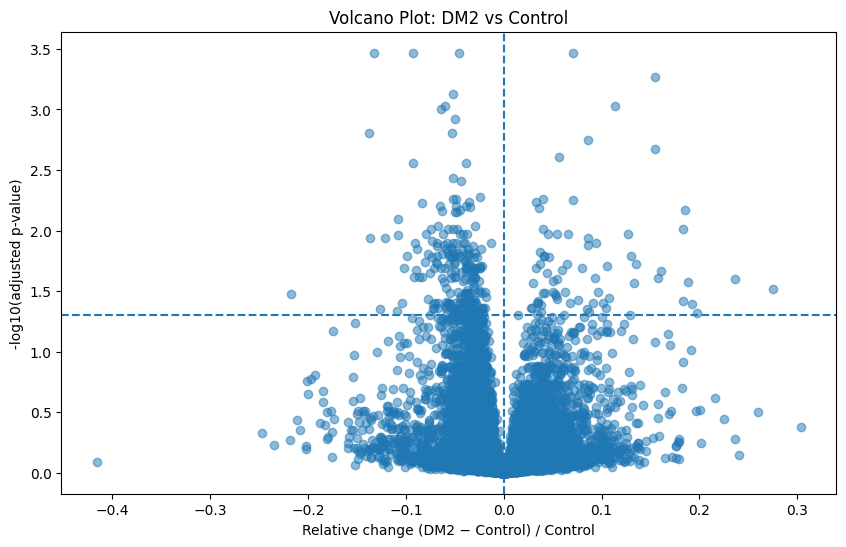

In [81]:
import matplotlib.pyplot as plt

# Creating a volcano plot showing expression change versus statistical significance

plt.figure(figsize=(10, 6))

plt.scatter(
    feature_results["Relative_change"],
    feature_results["neg_log10_adj_p"],
    alpha=0.5
)

plt.xlabel("Relative change (DM2 − Control) / Control")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot: DM2 vs Control")

plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(0, linestyle="--")

plt.show()

In [82]:
import numpy as np

# Calculating log2 fold change for each feature
# Positive values indicate higher expression in DM2,
# while negative values indicate lower expression in DM2

feature_results["log2_fold_change"] = np.log2(
    feature_results["DM2_mean"] / feature_results["Control_mean"]
)

feature_results.head()

,Control_mean,DM2_mean,Difference,ID_REF,Relative_change,p_value,adjusted_p_value,neg_log10_adj_p,log2_fold_change
0,6.454,6.482,0.028,2315554,0.004338,0.832085,0.968094,0.014082,0.006245
1,6.510,6.541,0.031,2315633,0.004762,0.712631,0.945892,0.024159,0.006854
2,6.394,6.472,0.078,2315674,0.012199,0.578424,0.910905,0.040527,0.017493
3,6.525,6.505,-0.020,2315739,-0.003065,0.824270,0.966063,0.014995,-0.004429
4,8.639,8.658,0.019,2315894,0.002199,0.878524,0.979433,0.009025,0.003169


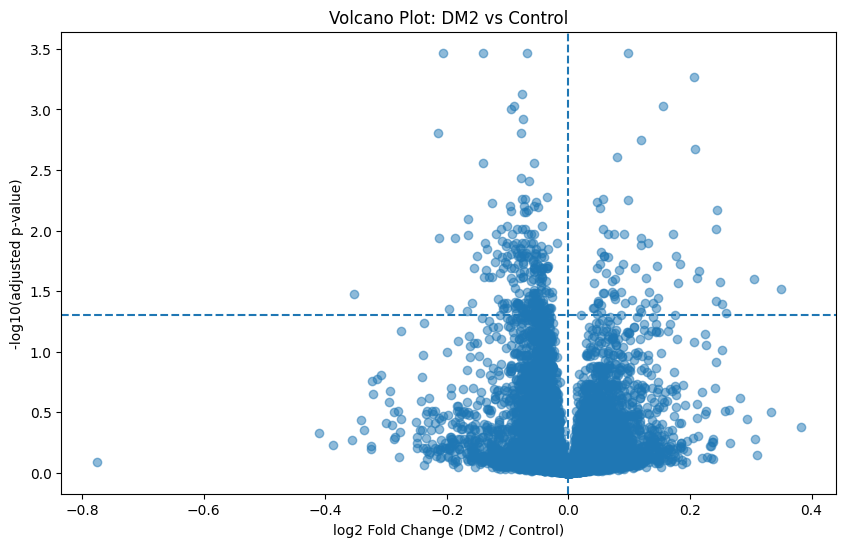

In [84]:
# Creating a standard volcano plot using log2 fold change
# and FDR-adjusted statistical significance

plt.figure(figsize=(10, 6))

plt.scatter(
    feature_results["log2_fold_change"],
    feature_results["neg_log10_adj_p"],
    alpha=0.5
)

# Adding the FDR significance threshold (adjusted p-value = 0.05)

plt.axhline(-np.log10(0.05), linestyle="--")

# Adding the zero fold-change reference line

plt.axvline(0, linestyle="--")

plt.xlabel("log2 Fold Change (DM2 / Control)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot: DM2 vs Control")

plt.show()

In [85]:
# Recreating the FDR-significant feature table from the updated results
# so that it includes the newly calculated log2 fold change
significant_features = feature_results[

    feature_results["adjusted_p_value"] < 0.05
]

significant_features_sorted = significant_features.sort_values(
    "adjusted_p_value"
)

significant_features_sorted[
    ["ID_REF", "log2_fold_change", "adjusted_p_value"]
].head(10)

,ID_REF,log2_fold_change,adjusted_p_value
12475,3396916,-0.067597,0.000340
15305,3608466,-0.141074,0.000340
15056,3580498,0.098592,0.000340
16342,3695541,-0.205933,0.000340
11389,3333086,0.206834,0.000540
9337,3155937,-0.076272,0.000742
4597,2694644,-0.089310,0.000934
10257,3252577,0.154918,0.000934
18786,3830051,-0.095227,0.000988
7824,2983142,-0.074193,0.001190


In [86]:
# Displaying the first few probe IDs that need annotation
# so we can confirm the identifiers match the GPL5175 platform

feature_results["ID_REF"].head(10)

,ID_REF
0,2315554
1,2315633
2,2315674
3,2315739
4,2315894
5,2315918
6,2315951
7,2316218
8,2316245
9,2316379


In [87]:
# Calculating the correct log2 fold change.
# Because the expression values are already on a log2 scale,
# subtracting the Control mean from the DM2 mean gives log2FC.

feature_results["log2_fold_change"] = (
    feature_results["DM2_mean"] - feature_results["Control_mean"]
)

# Check that log2FC is identical to our previously calculated Difference column
print(
    "Maximum difference between Difference and log2FC:",
    (feature_results["Difference"] - feature_results["log2_fold_change"]).abs().max()
)

# Display the first few values for verification
feature_results[
    ["ID_REF", "Control_mean", "DM2_mean", "Difference", "log2_fold_change"]
].head()

Maximum difference between Difference and log2FC: 0.0


,ID_REF,Control_mean,DM2_mean,Difference,log2_fold_change
0,2315554,6.454,6.482,0.028,0.028
1,2315633,6.510,6.541,0.031,0.031
2,2315674,6.394,6.472,0.078,0.078
3,2315739,6.525,6.505,-0.020,-0.020
4,2315894,8.639,8.658,0.019,0.019


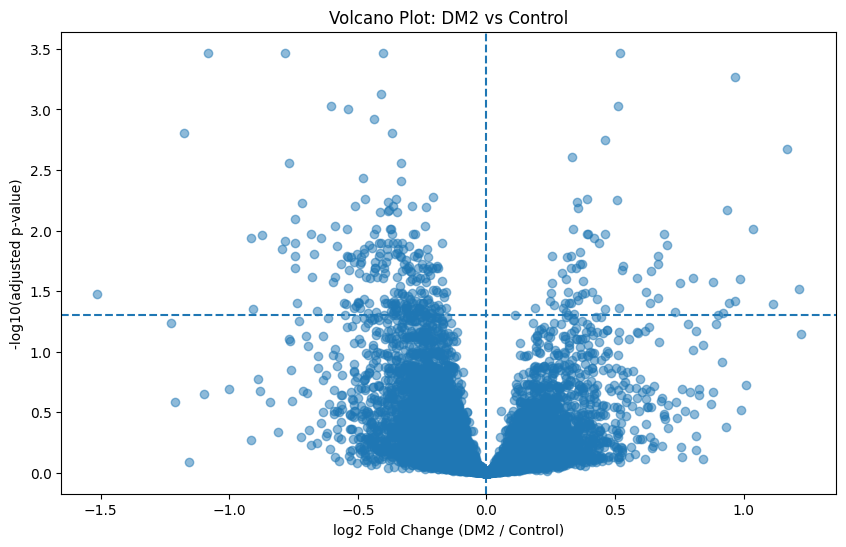

In [88]:
# Creating the volcano plot using the corrected log2 fold change
# and the FDR-adjusted p-values.

plt.figure(figsize=(10, 6))

plt.scatter(
    feature_results["log2_fold_change"],
    feature_results["neg_log10_adj_p"],
    alpha=0.5
)

# Add the significance threshold at adjusted p-value = 0.05
plt.axhline(
    -np.log10(0.05),
    linestyle="--"
)

# Add a vertical reference line at log2FC = 0
plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("log2 Fold Change (DM2 / Control)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot: DM2 vs Control")

plt.show()

In [89]:
# Selecting all features that remain statistically significant
# after False Discovery Rate (FDR) correction.

significant_features = feature_results[
    feature_results["adjusted_p_value"] < 0.05
].copy()

# Keeping only the columns that are most useful for reporting results.
final_significant_table = significant_features[
    [
        "ID_REF",
        "Control_mean",
        "DM2_mean",
        "log2_fold_change",
        "p_value",
        "adjusted_p_value"
    ]
].sort_values("adjusted_p_value")

# Displaying the first 10 most statistically significant features.
final_significant_table.head(10)

,ID_REF,Control_mean,DM2_mean,log2_fold_change,p_value,adjusted_p_value
12475,3396916,8.826,8.422,-0.404,4.377032e-08,0.000340
15305,3608466,8.416,7.632,-0.784,6.175138e-08,0.000340
15056,3580498,7.338,7.857,0.519,4.799667e-08,0.000340
16342,3695541,8.149,7.065,-1.084,2.170927e-08,0.000340
11389,3333086,6.273,7.240,0.967,1.227481e-07,0.000540
9337,3155937,7.962,7.552,-0.410,2.022654e-07,0.000742
4597,2694644,10.062,9.458,-0.604,3.084435e-07,0.000934
10257,3252577,4.499,5.009,0.510,3.395006e-07,0.000934
18786,3830051,8.407,7.870,-0.537,4.038356e-07,0.000988
7824,2983142,8.698,8.262,-0.436,5.404441e-07,0.001190


In [90]:
# Separating statistically significant features into:
# 1. Higher expression in DM2 (positive log2FC)
# 2. Lower expression in DM2 (negative log2FC)

upregulated_features = final_significant_table[
    final_significant_table["log2_fold_change"] > 0
].copy()

downregulated_features = final_significant_table[
    final_significant_table["log2_fold_change"] < 0
].copy()

# Printing the number of significant features in each direction.

print("Upregulated features:", len(upregulated_features))
print("Downregulated features:", len(downregulated_features))

# Displaying the 10 strongest increases.
print("\nTop 10 increased features:")
display(
    upregulated_features.sort_values(
        "log2_fold_change",
        ascending=False
    ).head(10)
)

# Displaying the 10 strongest decreases.
print("\nTop 10 decreased features:")
display(
    downregulated_features.sort_values(
        "log2_fold_change",
        ascending=True
    ).head(10)
)

Upregulated features: 72
Downregulated features: 232

Top 10 increased features:


,ID_REF,Control_mean,DM2_mean,log2_fold_change,p_value,adjusted_p_value
19883,3875179,4.421,5.636,1.215,2.400451e-04,0.030192
3071,2550959,7.547,8.714,1.167,1.346199e-06,0.002117
14293,3541383,5.800,6.914,1.114,4.286855e-04,0.040056
21695,4011096,5.654,6.691,1.037,1.886719e-05,0.009650
7891,2992243,4.172,5.156,0.984,1.850805e-04,0.025147
18879,3831475,5.295,6.263,0.968,3.648432e-04,0.038393
11389,3333086,6.273,7.240,0.967,1.227481e-07,0.000540
5778,2830450,9.311,10.253,0.942,4.159012e-04,0.039493
5513,2794408,5.049,5.983,0.934,1.033113e-05,0.006820
617,2348437,4.659,5.578,0.919,6.266001e-04,0.048224



Top 10 decreased features:


,ID_REF,Control_mean,DM2_mean,log2_fold_change,p_value,adjusted_p_value
1949,2441220,6.985,5.469,-1.516,2.966765e-04,0.033661
4852,2723752,8.521,7.347,-1.174,7.782817e-07,0.001553
16342,3695541,8.149,7.065,-1.084,2.170927e-08,0.000340
18203,3806211,7.553,6.636,-0.917,3.059873e-05,0.011415
6341,2853885,7.133,6.227,-0.906,5.266037e-04,0.044242
16712,3718555,8.068,7.195,-0.873,2.776800e-05,0.010914
9770,3203990,8.975,8.180,-0.795,4.857006e-05,0.014179
15305,3608466,8.416,7.632,-0.784,6.175138e-08,0.000340
19937,3881503,10.732,9.950,-0.782,3.340434e-05,0.012254
2820,2534694,8.286,7.520,-0.766,2.142764e-06,0.002774


In [91]:
# Selecting the 10 strongest increases and 10 strongest decreases
# based on their log2 fold change values.

top_increased = upregulated_features.sort_values(
    "log2_fold_change",
    ascending=False
).head(10)

top_decreased = downregulated_features.sort_values(
    "log2_fold_change",
    ascending=True
).head(10)

# Combining both groups into one table for visualization.

top_features = pd.concat(
    [top_increased, top_decreased]
)

# Sorting from the strongest decrease to the strongest increase.

top_features = top_features.sort_values(
    "log2_fold_change"
)

# Displaying the selected features.
top_features[
    ["ID_REF", "log2_fold_change", "adjusted_p_value"]
]

,ID_REF,log2_fold_change,adjusted_p_value
1949,2441220,-1.516,0.033661
4852,2723752,-1.174,0.001553
16342,3695541,-1.084,0.000340
18203,3806211,-0.917,0.011415
6341,2853885,-0.906,0.044242
16712,3718555,-0.873,0.010914
9770,3203990,-0.795,0.014179
15305,3608466,-0.784,0.000340
19937,3881503,-0.782,0.012254
2820,2534694,-0.766,0.002774


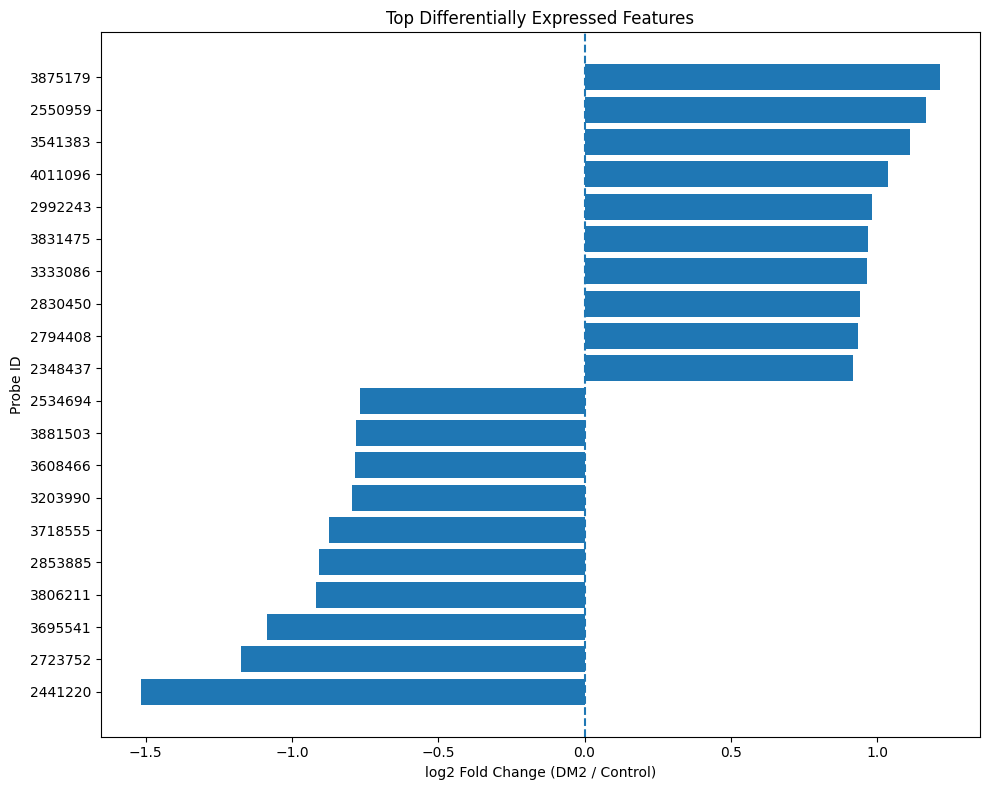

In [92]:
# Creating a ranked bar plot of the 20 strongest significant features.
# Negative values represent lower expression in DM2,
# while positive values represent higher expression in DM2.

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["ID_REF"].astype(str),
    top_features["log2_fold_change"]
)

# Add a vertical reference line at zero.
plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("log2 Fold Change (DM2 / Control)")
plt.ylabel("Probe ID")
plt.title("Top Differentially Expressed Features")

plt.tight_layout()
plt.show()

In [93]:
# Performing Principal Component Analysis (PCA) on the 20 samples.
# PCA summarizes the largest sources of variation across all expression features.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Transposing the expression matrix so that:
# rows = samples
# columns = expression features

expression_for_pca = clean_sample_df.T

# Standardizing each feature before PCA.
# This prevents features with larger variance from dominating the analysis.

scaled_expression = StandardScaler().fit_transform(
    expression_for_pca
)

# Calculating the first two principal components.

pca = PCA(n_components=2)

pca_coordinates = pca.fit_transform(
    scaled_expression
)

# Creating a table containing the PCA coordinates and sample group.

pca_df = pd.DataFrame(
    pca_coordinates,
    columns=["PC1", "PC2"],
    index=expression_for_pca.index
)

# Assigning Control or DM2 labels to each sample.

pca_df["Group"] = [
    "Control" if sample in groups["Control"] else "DM2"
    for sample in pca_df.index
]

# Displaying the percentage of variance explained by each component.

print(
    "PC1 variance explained:",
    round(pca.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "PC2 variance explained:",
    round(pca.explained_variance_ratio_[1] * 100, 2),
    "%"
)

# Displaying the PCA coordinates.

pca_df

PC1 variance explained: 29.89 %
PC2 variance explained: 11.45 %


,PC1,PC2,Group
GSM910396,-19.147605,70.725154,Control
GSM910397,10.604963,79.055966,Control
GSM910398,-29.506468,19.338395,Control
GSM910399,-14.586221,39.847066,Control
GSM910400,-48.073759,-26.535571,Control
GSM910401,-73.679670,10.989609,Control
GSM910402,6.479284,-5.083041,Control
GSM910403,8.541558,33.262309,Control
GSM910404,103.846178,41.477913,Control
GSM910405,-88.370058,-2.224569,Control


In [94]:
# Performing PCA again, this time using centered expression values
# without scaling every feature to unit variance.
# This is useful for checking whether the previous PCA pattern
# was influenced by feature-wise standardization.

from sklearn.decomposition import PCA

# Transposing the expression matrix:
# rows = samples, columns = expression features

expression_for_pca = clean_sample_df.T

# Centering each feature by subtracting its mean.
# We do not divide by its standard deviation.

centered_expression = (
    expression_for_pca
    - expression_for_pca.mean(axis=0)
)

# Calculating the first two principal components.

pca_centered = PCA(n_components=2)

pca_coordinates_centered = pca_centered.fit_transform(
    centered_expression
)

# Creating a table containing the PCA coordinates and sample groups.

pca_centered_df = pd.DataFrame(
    pca_coordinates_centered,
    columns=["PC1", "PC2"],
    index=expression_for_pca.index
)

# Assigning Control or DM2 labels to each sample.

pca_centered_df["Group"] = [
    "Control" if sample in groups["Control"] else "DM2"
    for sample in pca_centered_df.index
]

# Reporting how much variation is explained by PC1 and PC2.

print(
    "PC1 variance explained:",
    round(pca_centered.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "PC2 variance explained:",
    round(pca_centered.explained_variance_ratio_[1] * 100, 2),
    "%"
)

# Displaying the PCA coordinates.

pca_centered_df

PC1 variance explained: 25.83 %
PC2 variance explained: 11.77 %


,PC1,PC2,Group
GSM910396,5.087156,-15.470283,Control
GSM910397,-2.638871,-17.518699,Control
GSM910398,8.320286,-5.643092,Control
GSM910399,4.197884,-10.977732,Control
GSM910400,10.713858,0.761573,Control
GSM910401,20.335496,-2.869288,Control
GSM910402,-0.221353,0.948056,Control
GSM910403,-2.626413,-7.281994,Control
GSM910404,-28.243459,-11.338254,Control
GSM910405,23.746405,-1.379764,Control


In [95]:
# Calculating Pearson correlation between every pair of samples.
# This checks how similar the overall expression profiles are
# between the 20 samples.

# Transposing the expression matrix so that:
# rows = samples
# columns = expression features

sample_expression = clean_sample_df.T

# Calculating the sample-to-sample Pearson correlation matrix.

sample_correlation = sample_expression.T.corr()

# Displaying the correlation matrix.

sample_correlation

,GSM910396,GSM910397,GSM910398,GSM910399,GSM910400,GSM910401,GSM910402,GSM910403,GSM910404,GSM910405,GSM910406,GSM910407,GSM910408,GSM910409,GSM910410,GSM910411,GSM910412,GSM910413,GSM910414,GSM910415
GSM910396,1.000000,0.986450,0.982927,0.983823,0.976685,0.980762,0.980865,0.982650,0.979516,0.977949,0.986395,0.984626,0.960574,0.967608,0.953153,0.981362,0.975770,0.984589,0.985388,0.967460
GSM910397,0.986450,1.000000,0.982981,0.983362,0.977185,0.978468,0.980595,0.983934,0.982452,0.975454,0.986550,0.983008,0.959779,0.961980,0.956249,0.979268,0.972768,0.982277,0.986007,0.969680
GSM910398,0.982927,0.982981,1.000000,0.982040,0.979597,0.980608,0.980779,0.983784,0.976331,0.979306,0.983997,0.982644,0.963289,0.972040,0.953259,0.981661,0.979058,0.982837,0.984158,0.968458
GSM910399,0.983823,0.983362,0.982040,1.000000,0.980123,0.978005,0.980392,0.981244,0.975960,0.978995,0.982333,0.980129,0.959175,0.968083,0.953180,0.981562,0.975854,0.981526,0.983611,0.967999
GSM910400,0.976685,0.977185,0.979597,0.980123,1.000000,0.977098,0.976247,0.976916,0.970862,0.981617,0.976600,0.972776,0.959573,0.970610,0.951144,0.977250,0.978755,0.976740,0.979444,0.960988
GSM910401,0.980762,0.978468,0.980608,0.978005,0.977098,1.000000,0.981344,0.979991,0.967320,0.977743,0.977708,0.974892,0.959772,0.974166,0.943329,0.978565,0.979358,0.979692,0.978191,0.958059
GSM910402,0.980865,0.980595,0.980779,0.980392,0.976247,0.981344,1.000000,0.984834,0.976584,0.978042,0.980789,0.979844,0.964235,0.968067,0.959733,0.981818,0.979466,0.980223,0.981879,0.971362
GSM910403,0.982650,0.983934,0.983784,0.981244,0.976916,0.979991,0.984834,1.000000,0.980879,0.977145,0.983637,0.981809,0.962415,0.965963,0.960521,0.981749,0.976330,0.981646,0.984626,0.972627
GSM910404,0.979516,0.982452,0.976331,0.975960,0.970862,0.967320,0.976584,0.980879,1.000000,0.965995,0.983867,0.982525,0.958023,0.948084,0.973373,0.973919,0.964947,0.977827,0.984087,0.979571
GSM910405,0.977949,0.975454,0.979306,0.978995,0.981617,0.977743,0.978042,0.977145,0.965995,1.000000,0.976686,0.975239,0.957822,0.975354,0.940920,0.981103,0.983626,0.980658,0.976775,0.956782


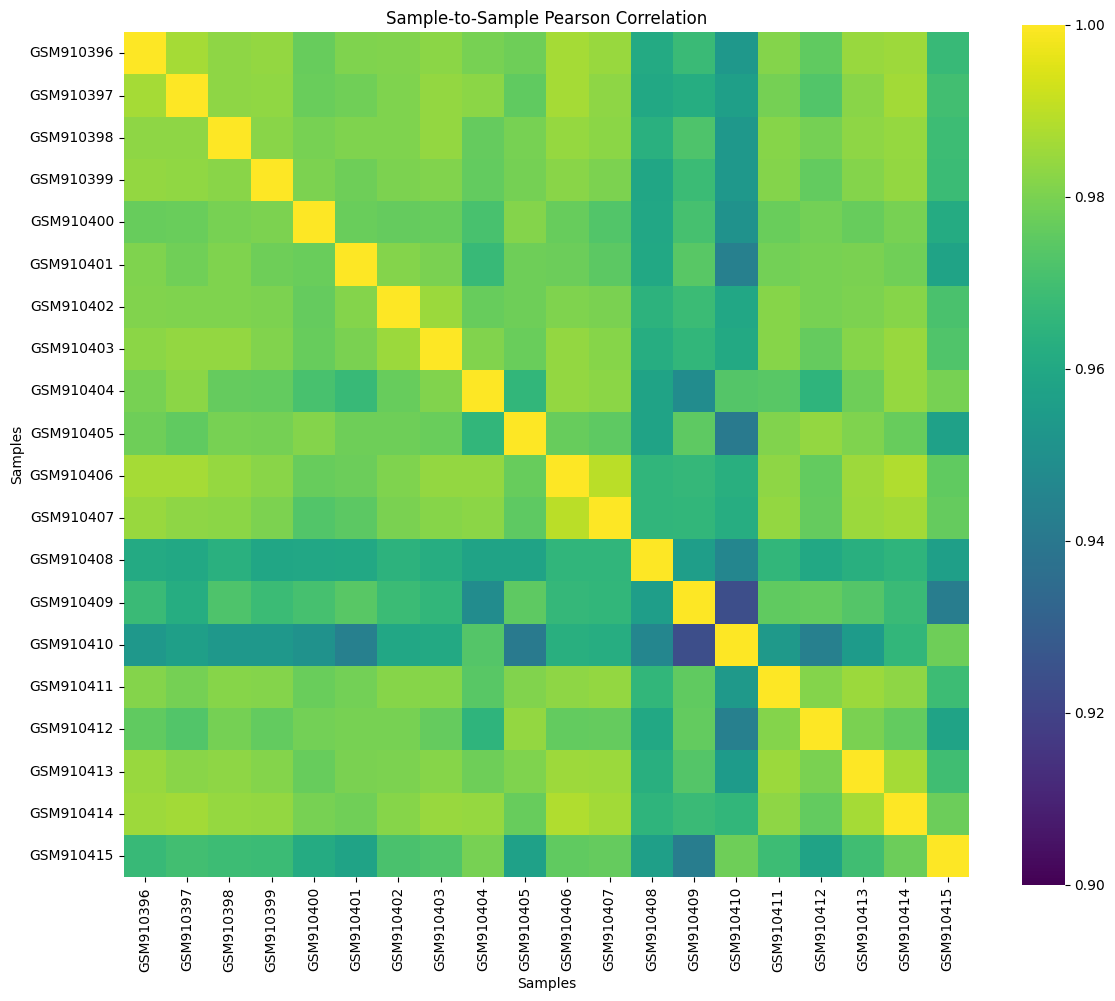

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the sample-to-sample Pearson correlation matrix.
# Highly correlated samples should appear with similar colors,
# making possible unusual samples easier to identify visually.

plt.figure(figsize=(12, 10))

sns.heatmap(
    sample_correlation,
    cmap="viridis",
    vmin=0.90,
    vmax=1.00,
    square=True
)

plt.title("Sample-to-Sample Pearson Correlation")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

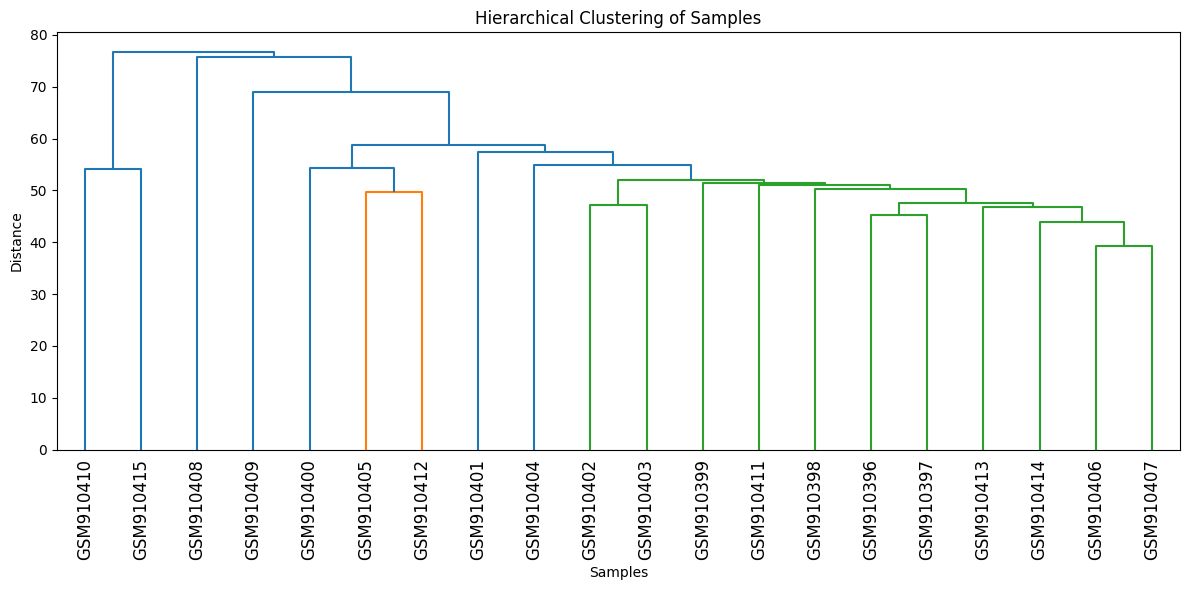

In [97]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Performing hierarchical clustering using the sample expression profiles.
# Each sample is represented by its expression across all features.

sample_expression = clean_sample_df.T

# Calculating the hierarchical clustering linkage.
# "average" uses average distance between clusters.

linkage_matrix = linkage(
    sample_expression,
    method="average",
    metric="euclidean"
)

# Plotting the resulting sample dendrogram.

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    labels=sample_expression.index,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Samples")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [98]:
import numpy as np

# Calculating the average PCA position for each biological group.
# This gives us the center (centroid) of the Control and DM2 samples.

control_centroid = pca_coordinates_centered[
    pca_centered_df["Group"] == "Control"
].mean(axis=0)

dm2_centroid = pca_coordinates_centered[
    pca_centered_df["Group"] == "DM2"
].mean(axis=0)

# Calculating the Euclidean distance between the two group centroids.

centroid_distance = np.linalg.norm(
    control_centroid - dm2_centroid
)

print("Control centroid:", control_centroid)
print("DM2 centroid:", dm2_centroid)
print("Distance between group centroids:", centroid_distance)

Control centroid: [ 3.86709882 -7.07694781]
DM2 centroid: [-3.86709882  7.07694781]
Distance between group centroids: 16.12918393815587


In [99]:
# Counting significantly differentially expressed features
# using the BH-adjusted p-value threshold of 0.05.

significant = feature_results[
    feature_results["adjusted_p_value"] < 0.05
]

# Separating significant features according to the direction
# of their expression change in DM2 relative to Control.

upregulated = significant[
    significant["log2_fold_change"] > 0
]

downregulated = significant[
    significant["log2_fold_change"] < 0
]

print("Total features:", len(feature_results))
print("Significant features:", len(significant))
print("Significantly increased in DM2:", len(upregulated))
print("Significantly decreased in DM2:", len(downregulated))

Total features: 22011
Significant features: 304
Significantly increased in DM2: 72
Significantly decreased in DM2: 232


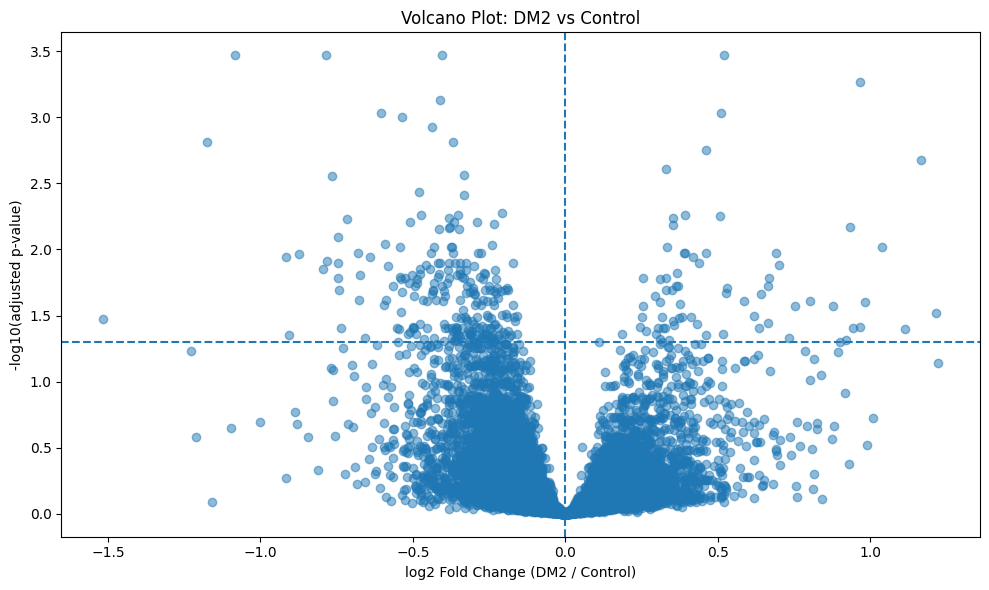

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Creating the final volcano plot using the corrected log2 fold change.
# Because the expression data are already log2-transformed,
# log2 fold change = DM2 mean - Control mean.

plt.figure(figsize=(10, 6))

plt.scatter(
    feature_results["log2_fold_change"],
    feature_results["neg_log10_adj_p"],
    alpha=0.5
)

# Marking the adjusted p-value significance threshold.

plt.axhline(
    -np.log10(0.05),
    linestyle="--"
)

# Marking zero log2 fold change (no change between groups).
plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("log2 Fold Change (DM2 / Control)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot: DM2 vs Control")

plt.tight_layout()
plt.show()

In [101]:
# Selecting the 10 most increased and 10 most decreased
# significant expression features in DM2.

top_increased = (
    upregulated
    .sort_values("log2_fold_change", ascending=False)
    .head(10)
)

top_decreased = (
    downregulated
    .sort_values("log2_fold_change", ascending=True)
    .head(10)
)

# Combining both groups into one final table.

top_20_features = pd.concat(
    [top_increased, top_decreased]
)

# Keeping only the columns needed for the final report.
top_20_table = top_20_features[
    [
        "ID_REF",
        "Control_mean",
        "DM2_mean",
        "log2_fold_change",
        "p_value",
        "adjusted_p_value"
    ]
].sort_values(
    "log2_fold_change",
    ascending=False
)

top_20_table

,ID_REF,Control_mean,DM2_mean,log2_fold_change,p_value,adjusted_p_value
19883,3875179,4.421,5.636,1.215,2.400451e-04,0.030192
3071,2550959,7.547,8.714,1.167,1.346199e-06,0.002117
14293,3541383,5.800,6.914,1.114,4.286855e-04,0.040056
21695,4011096,5.654,6.691,1.037,1.886719e-05,0.009650
7891,2992243,4.172,5.156,0.984,1.850805e-04,0.025147
18879,3831475,5.295,6.263,0.968,3.648432e-04,0.038393
11389,3333086,6.273,7.240,0.967,1.227481e-07,0.000540
5778,2830450,9.311,10.253,0.942,4.159012e-04,0.039493
5513,2794408,5.049,5.983,0.934,1.033113e-05,0.006820
617,2348437,4.659,5.578,0.919,6.266001e-04,0.048224


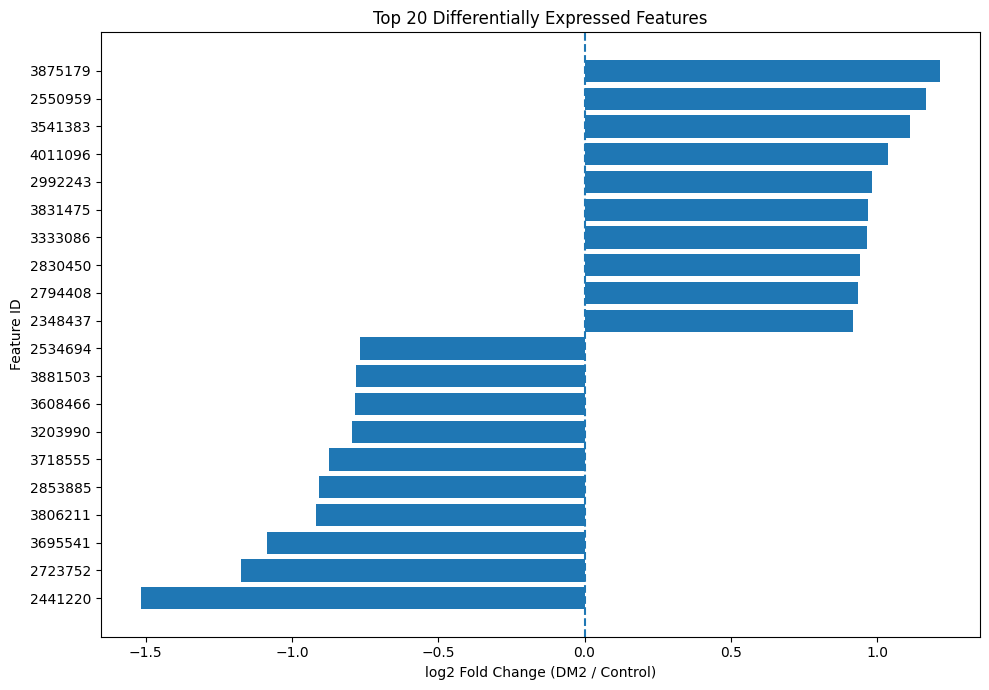

In [102]:
import matplotlib.pyplot as plt

# Sorting the top 20 features by log2 fold change so that
# decreased features appear at the bottom and increased
# features appear at the top of the horizontal bar chart.

plot_data = top_20_table.sort_values(
    "log2_fold_change"
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["ID_REF"].astype(str),
    plot_data["log2_fold_change"]
)

# Adding a vertical reference line at zero.
# Values to the left are decreased in DM2;
# values to the right are increased in DM2.

plt.axvline(0, linestyle="--")

plt.xlabel("log2 Fold Change (DM2 / Control)")
plt.ylabel("Feature ID")
plt.title("Top 20 Differentially Expressed Features")

plt.tight_layout()
plt.show()

In [103]:
# Saving the complete differential-expression results.
# This CSV contains all 22,011 tested features, including
# expression means, log2 fold change, p-values, and FDR-adjusted p-values.

final_results = feature_results[
    [
        "ID_REF",
        "Control_mean",
        "DM2_mean",
        "log2_fold_change",
        "p_value",
        "adjusted_p_value"
    ]
].sort_values(
    "adjusted_p_value"
)

final_results.to_csv(
    "DM2_vs_Control_differential_expression_results.csv",
    index=False
)

print("CSV export completed.")
print("Rows exported:", len(final_results))
print("Columns exported:", len(final_results.columns))

CSV export completed.
Rows exported: 22011
Columns exported: 6


## Conclusion

* **22,011** expression features were analyzed across 20 samples.
* **304 features** were significantly different between DM2 and Control after Benjamini–Hochberg FDR correction (adjusted p < 0.05).
* **72 features** showed increased expression and **232 features** showed decreased expression in DM2.
* PCA, correlation analysis, and hierarchical clustering showed substantial sample-level variation, with **no complete separation between Control and DM2 groups**.
* The reported identifiers represent **expression features/probes rather than annotated genes**, so gene-specific and pathway-level conclusions were not made.
* The complete differential-expression results were exported as `DM2_vs_Control_differential_expression_results.csv`.

**Overall:** The analysis identified a subset of expression features associated with the DM2 versus Control comparison while demonstrating substantial biological/sample-level variation that should be considered when interpreting the results.

In [104]:
# Listing the PNG files currently saved in the Colab working directory

import os

for file in os.listdir():
    if file.endswith(".png"):
        print(file)

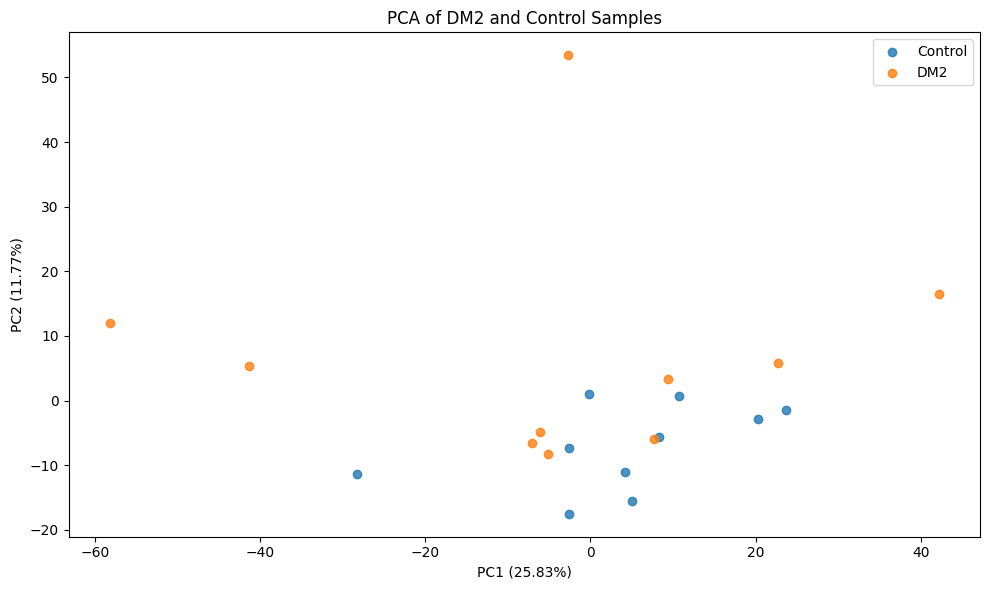

In [105]:
# Recreating and save the final centered PCA plot for the GitHub repository

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for group in ["Control", "DM2"]:
    group_data = pca_centered_df[pca_centered_df["Group"] == group]

    plt.scatter(
        group_data["PC1"],
        group_data["PC2"],
        label=group,
        alpha=0.8
    )

plt.xlabel("PC1 (25.83%)")
plt.ylabel("PC2 (11.77%)")
plt.title("PCA of DM2 and Control Samples")
plt.legend()
plt.tight_layout()

# Saving the figure as a high-resolution image

plt.savefig("pca_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [106]:
# Checking which major analysis results are currently available in memory

variables_to_check = [
    "feature_results",
    "pca_centered_df",
    "sample_correlation",
    "linkage_matrix",
    "significant_features"
]

for variable in variables_to_check:
    print(variable, "->", variable in globals())

feature_results -> True
pca_centered_df -> True
sample_correlation -> True
linkage_matrix -> True
significant_features -> True


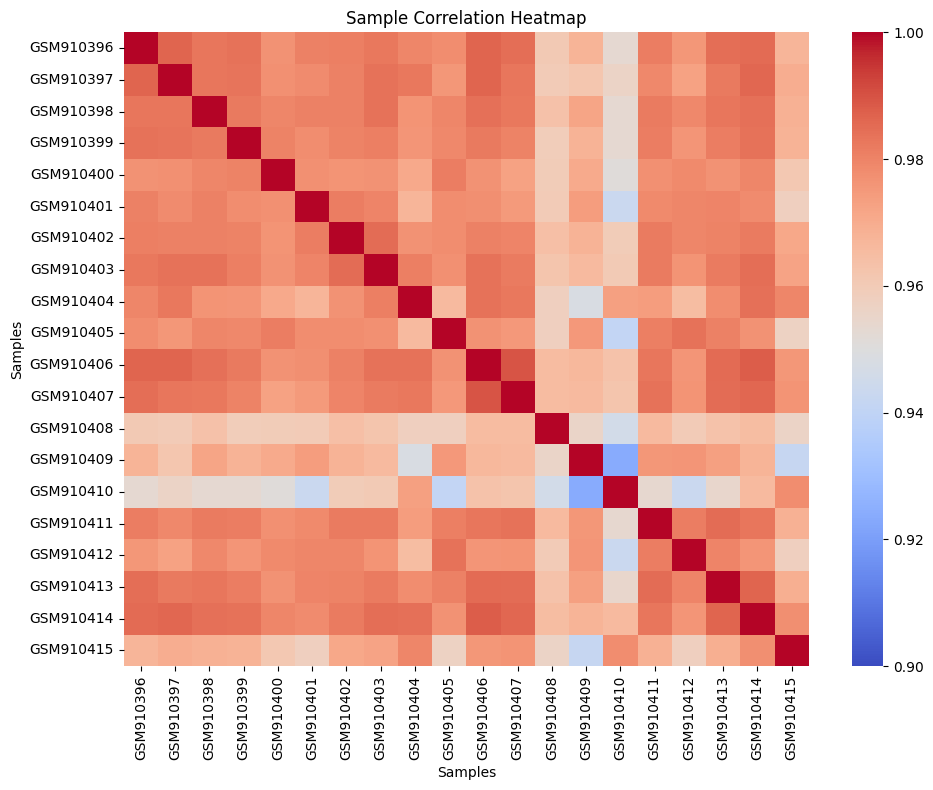

Saved: correlation_heatmap.png


In [107]:
# Saving the sample correlation heatmap for the GitHub repository

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    sample_correlation,
    cmap="coolwarm",
    vmin=0.9,
    vmax=1.0
)

plt.title("Sample Correlation Heatmap")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: correlation_heatmap.png")

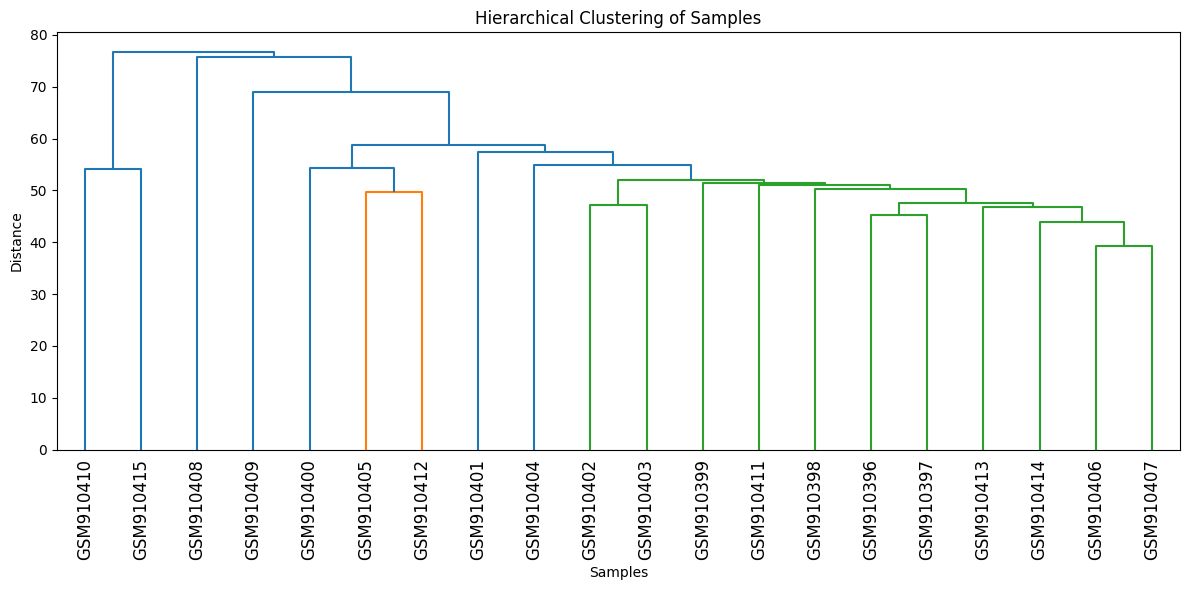

Saved: hierarchical_clustering.png


In [108]:
# Saving the hierarchical clustering plot for the GitHub repository

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    labels=sample_expression.index,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Samples")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()

plt.savefig("hierarchical_clustering.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: hierarchical_clustering.png")

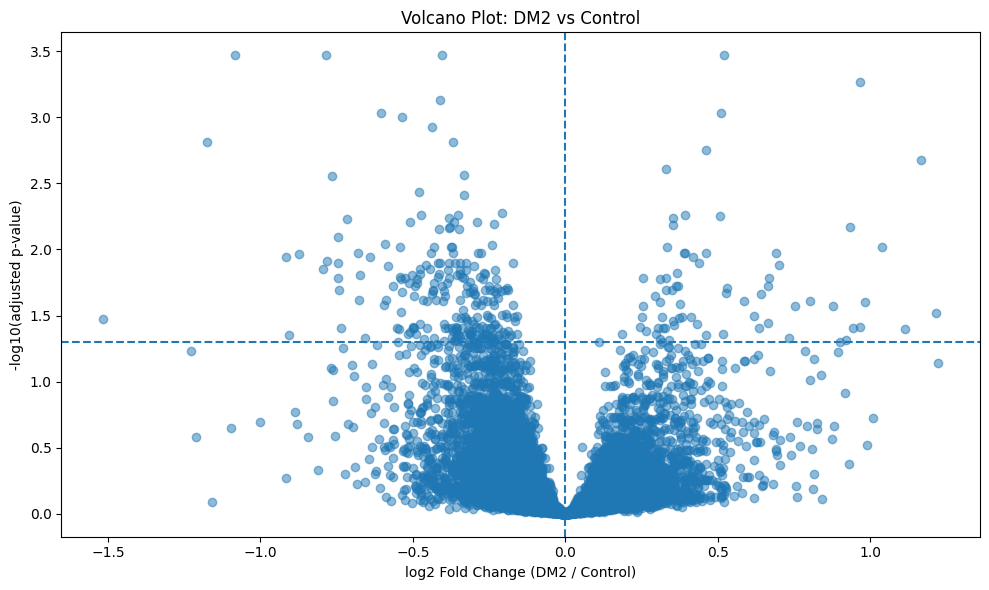

Saved: volcano_plot.png


In [109]:
# Saving the volcano plot for the GitHub repository

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.scatter(
    feature_results["log2_fold_change"],
    feature_results["neg_log10_adj_p"],
    alpha=0.5
)

# Significance threshold: adjusted p-value = 0.05

plt.axhline(
    -np.log10(0.05),
    linestyle="--"
)

# No-change reference line

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("log2 Fold Change (DM2 / Control)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot: DM2 vs Control")

plt.tight_layout()

plt.savefig(
    "volcano_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: volcano_plot.png")

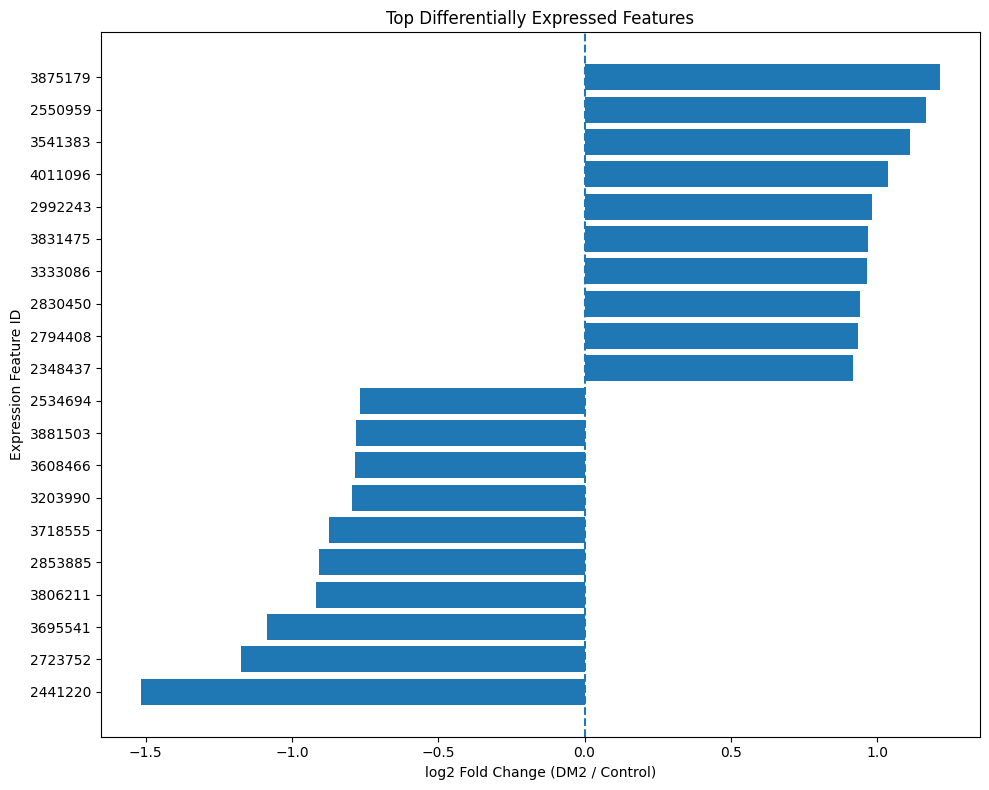

Saved: top_differential_features.png


In [110]:
# Saving the top differential features plot for the GitHub repository

import matplotlib.pyplot as plt
import pandas as pd

# Selecting the most increased features

top_increased = significant_features.sort_values(
    "log2_fold_change",
    ascending=False
).head(10)

# Selecting the most decreased features

top_decreased = significant_features.sort_values(
    "log2_fold_change",
    ascending=True
).head(10)

# Combining the two groups

top_features = pd.concat(
    [top_increased, top_decreased]
)

# Sorting for plotting
top_features = top_features.sort_values(
    "log2_fold_change"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["ID_REF"].astype(str),
    top_features["log2_fold_change"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("log2 Fold Change (DM2 / Control)")
plt.ylabel("Expression Feature ID")
plt.title("Top Differentially Expressed Features")

plt.tight_layout()

plt.savefig(
    "top_differential_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: top_differential_features.png")

In [111]:
import os

files_to_check = [
    "pca_plot.png",
    "correlation_heatmap.png",
    "hierarchical_clustering.png",
    "volcano_plot.png",
    "top_differential_features.png",
    "DM2_vs_Control_differential_expression_results.csv"
]

for file in files_to_check:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

✓ pca_plot.png
✓ correlation_heatmap.png
✓ hierarchical_clustering.png
✓ volcano_plot.png
✓ top_differential_features.png
✓ DM2_vs_Control_differential_expression_results.csv
